In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from GaussNewtonEst import GaussNewtonAI

/home/alan/Documents/Projects/School_Experiments/School_Notes/Num_Analysis/M2/src/GaussNewtonEst.py:1: SyntaxWarning: invalid escape sequence '\d'
  """
/home/alan/Documents/Projects/School_Experiments/School_Notes/Num_Analysis/M2/src/GaussNewtonEst.py:38: SyntaxWarning: invalid escape sequence '\d'
  """


### Class Implementation to fit the model. 

In [7]:
# We begin with the same data as before:
data = pd.read_csv("/home/alan/Documents/Projects/School_Experiments/School_Notes/Num_Analysis/M2/data/water_quality.csv")

data.rename(columns = {"ESTACION": "site",
                       "fecha": "date",
                       "CLOROF_A": "clorof_a",
                       "OD_mg/L_FON": "od_fon",
                       "P_TOT": "p_tot",
                       "TEMP_AGUA_FON": "temp_fon"}, inplace = True)

data["date"] = pd.to_datetime(data["date"], format= "%d/%m/%Y")

data = data[data["site"] == "LAGO DE CHAPALA, ESTACION LACUSTRE 11"].copy()
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 18 entries, 301 to 318
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   site      18 non-null     str           
 1   date      18 non-null     datetime64[us]
 2   clorof_a  18 non-null     float64       
 3   od_fon    13 non-null     float64       
 4   p_tot     18 non-null     float64       
 5   temp_fon  14 non-null     float64       
dtypes: datetime64[us](1), float64(4), str(1)
memory usage: 996.0 bytes


In [9]:
x = data["p_tot"].values.reshape(-1, 1)
y = data["clorof_a"].values

# For easier and better outputs, we will standarize our data. 
scaler = StandardScaler()
scaled_x= scaler.fit_transform(x).flatten()

model = GaussNewtonAI()
model.fit(x = scaled_x, y = y)

y_hat = model.predict(x = scaled_x)

INFO: Gauss-Newton failed. Recovered successfully using 'curve_fit' fallback.


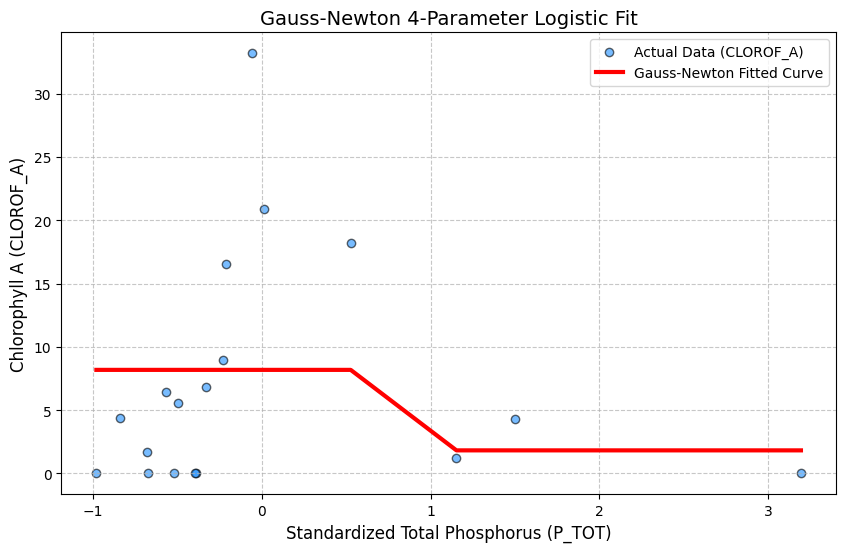

In [10]:
sort_indices = np.argsort(scaled_x)
x_sorted = scaled_x[sort_indices]
y_hat_sorted = y_hat[sort_indices]

plt.figure(figsize=(10, 6))

# Plot the original data points
plt.scatter(scaled_x, y, color='dodgerblue', alpha=0.6, edgecolors='k', label='Actual Data (CLOROF_A)')

# Plot the fitted logistic curve
plt.plot(x_sorted, y_hat_sorted, color='red', linewidth=3, label='Gauss-Newton Fitted Curve')

# Formatting the plot
plt.title('Gauss-Newton 4-Parameter Logistic Fit', fontsize=14)
plt.xlabel('Standardized Total Phosphorus (P_TOT)', fontsize=12)
plt.ylabel('Chlorophyll A (CLOROF_A)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

In [11]:
print(f"Final Parameters: [alpha={model.params[0]:.2f}, beta={model.params[1]:.2f}, delta={model.params[2]:.2f}, gamma={model.params[3]:.2f}]")

Final Parameters: [alpha=1.82, beta=0.88, delta=8.18, gamma=34.90]


As we can see, our algorithm (Gauss-Newton) failed, yet we were able to approximate a curve with our helper function:\
*curve_fit() from scipy.optimize* 